# Training Pipeline - Part 4: Autoencoder Training
## Cyber AI Agent v2.0.0

**Purpose:** Train unsupervised generative model for anomaly detection (Layer 5)

**Technique:** Denoising autoencoder for reconstruction-based anomaly detection

**Key Point:** Trained ONLY on benign traffic to learn normal patterns

**Inputs:**
- X_train_scaled.pkl (benign samples only)
- X_val_scaled.pkl (validation split from preprocessing; benign subset used here)
- X_test_scaled.pkl
- y_val.pkl
- y_test.pkl

**Outputs:**
- autoencoder.keras
- encoder_only.keras
- autoencoder_threshold.json
- autoencoder_metrics.json
- autoencoder_plots.png

---

## 1. Imports and Setup

In [8]:
# Section 1: Imports and Setup
import os
import time
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

os.makedirs('../trained_models', exist_ok=True)

print(f"✅ TensorFlow : {tf.__version__}")
print(f"✅ GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow : 2.20.0
✅ GPU        : False


## 2. Load Preprocessed Data

In [9]:
# Section 2: Load Preprocessed Data
print("\n📂 LOADING PREPROCESSED DATA")
print("=" * 60)

X_train = joblib.load('../datasets/X_train_scaled.pkl').values
X_val   = joblib.load('../datasets/X_val_scaled.pkl').values
X_test  = joblib.load('../datasets/X_test_scaled.pkl').values
y_train = joblib.load('../datasets/y_train.pkl').values
y_val   = joblib.load('../datasets/y_val.pkl').values
y_test  = joblib.load('../datasets/y_test.pkl').values

with open('../trained_models/reverse_map.json', 'r') as f:
    reverse_map = {int(k): v for k, v in json.load(f).items()}

print(f"✅ X_train : {X_train.shape}")
print(f"✅ X_val   : {X_val.shape}")
print(f"✅ X_test  : {X_test.shape}")

print(f"\nLabel distribution (train):")
for idx, name in sorted(reverse_map.items()):
    count = (y_train == idx).sum()
    print(f"  {idx} ({name:<15}): {count:,}")


📂 LOADING PREPROCESSED DATA
✅ X_train : (1932175, 18)
✅ X_val   : (241522, 18)
✅ X_test  : (241522, 18)

Label distribution (train):
  0 (BENIGN         ): 1,598,452
  1 (Bot            ): 1,559
  2 (DDoS           ): 102,100
  3 (DoS GoldenEye  ): 8,225
  4 (DoS Hulk       ): 133,552
  5 (DoS Slowhttptest): 4,142
  6 (DoS slowloris  ): 3,901
  7 (FTP-Patator    ): 3,413
  8 (Heartbleed     ): 9
  9 (Infiltration   ): 29
  10 (PortScan       ): 72,594
  11 (SSH-Patator    ): 2,521
  12 (Web Attack � Brute Force): 1,141
  13 (Web Attack � Sql Injection): 16
  14 (Web Attack � XSS): 521


In [10]:
# Section 3: Isolate Benign Traffic and Add Denoising Noise
print("\n⚠️  UNSUPERVISED TRAINING ON BENIGN DATA ONLY")
print("=" * 60)

# Isolate benign only
benign_mask_train = y_train == 0
benign_mask_val   = y_val   == 0

X_train_benign = X_train[benign_mask_train]
X_val_benign   = X_val[benign_mask_val]

print(f"\n1. Training data:")
print(f"   Total   : {X_train.shape[0]:,}")
print(f"   Benign  : {X_train_benign.shape[0]:,} ({X_train_benign.shape[0] / X_train.shape[0] * 100:.1f}%)")
print(f"   Attacks : {(~benign_mask_train).sum():,}")

print(f"\n2. Validation data:")
print(f"   Total         : {X_val.shape[0]:,}")
print(f"   Benign subset : {X_val_benign.shape[0]:,}")
print(f"   Attack samples: {(~benign_mask_val).sum():,}")

print(f"\n3. Rationale:")
print(f"   Autoencoder learns BENIGN reconstruction patterns.")
print(f"   Attack traffic → HIGH reconstruction error → anomaly.")

# Add noise (denoising autoencoder)
NOISE_FACTOR = 0.05
np.random.seed(42)

X_train_noisy = X_train_benign + NOISE_FACTOR * np.random.normal(size=X_train_benign.shape)
X_val_noisy   = X_val_benign   + NOISE_FACTOR * np.random.normal(size=X_val_benign.shape)

print(f"\n4. Denoising noise added:")
print(f"   Noise factor : {NOISE_FACTOR}")
print(f"   Train input  : noisy X  →  target: clean X")
print(f"   Val input    : noisy X  →  target: clean X")


⚠️  UNSUPERVISED TRAINING ON BENIGN DATA ONLY

1. Training data:
   Total   : 1,932,175
   Benign  : 1,598,452 (82.7%)
   Attacks : 333,723

2. Validation data:
   Total         : 241,522
   Benign subset : 199,806
   Attack samples: 41,716

3. Rationale:
   Autoencoder learns BENIGN reconstruction patterns.
   Attack traffic → HIGH reconstruction error → anomaly.

4. Denoising noise added:
   Noise factor : 0.05
   Train input  : noisy X  →  target: clean X
   Val input    : noisy X  →  target: clean X


In [11]:
# Extract test subsets and show samples
import os
os.makedirs('../trained_models', exist_ok=True)

# Split test set
X_test_benign = X_test[y_test == 0]
X_test_attack = X_test[y_test != 0]

print('X_test total:', X_test.shape)
print('X_test_benign:', X_test_benign.shape)
print('X_test_attack:', X_test_attack.shape)

# Show a few example rows
print('\nBenign samples (first 3):')
print(X_test_benign[:3])
print('\nAttack samples (first 3):')
print(X_test_attack[:3])

# Save for downstream analysis (optional)
np.save('../trained_models/X_test_benign.npy', X_test_benign)
np.save('../trained_models/X_test_attack.npy', X_test_attack)
print('\nSaved X_test_benign.npy and X_test_attack.npy in ../trained_models')

X_test total: (241522, 18)
X_test_benign: (199807, 18)
X_test_attack: (41715, 18)

Benign samples (first 3):
[[-0.4397007  -0.1757181   0.01355614  0.0041601   0.19200876 -0.00668435
   0.12896573 -0.33719374 -0.05149026 -0.22577677 -0.25184063 -0.24394728
  -0.14374037 -0.31099549 -0.22375179  0.         -0.00584462  0.        ]
 [-0.31503679 -0.48310067 -0.01189678 -0.0101915  -0.09313164 -0.00760601
  -0.29779979 -0.54131373  0.03561043  1.78331959 -0.31631171 -0.29805103
  -0.22056787 -0.60180713 -0.22375179  0.         -0.00584462  0.        ]
 [-0.46014767 -0.48221442 -0.01189678 -0.0101915  -0.08565157 -0.00756098
  -0.04690181 -0.37490734 -0.05131061 -0.22547727 -0.30961984 -0.29805103
  -0.22056787 -0.30679702 -0.22375179  0.         -0.00584462  0.        ]]

Attack samples (first 3):
[[-4.58739330e-01  1.39078598e+00 -5.53354932e-03 -5.40763447e-03
  -4.43615620e-02 -2.72881146e-03 -5.02471127e-02  2.45477890e+00
  -5.14973544e-02 -2.25792745e-01  9.69997788e-01  1.01878739e

## 4. Build Autoencoder

In [12]:
# Section 4: Build Autoencoder Architecture
print("\n🏗️  BUILDING AUTOENCODER ARCHITECTURE")
print("=" * 60)

INPUT_DIM    = X_train.shape[1]
ENCODING_DIM = 8

print(f"\nArchitecture:")
print(f"  Encoder : {INPUT_DIM} → 128 → 64 → 32 → 16 → {ENCODING_DIM} (bottleneck)")
print(f"  Decoder : {ENCODING_DIM} → 16 → 32 → 64 → 128 → {INPUT_DIM}")
print(f"  Regularization: BatchNorm + Dropout + L1 bottleneck + denoising input")

# Encoder
encoder_input = keras.Input(shape=(INPUT_DIM,), name='encoder_input')

x = layers.Dense(128, activation='relu', name='enc_1')(encoder_input)
x = layers.BatchNormalization(name='enc_bn_1')(x)
x = layers.Dropout(0.25, name='enc_drop_1')(x)

x = layers.Dense(64, activation='relu', name='enc_2')(x)
x = layers.BatchNormalization(name='enc_bn_2')(x)
x = layers.Dropout(0.20, name='enc_drop_2')(x)

x = layers.Dense(32, activation='relu', name='enc_3')(x)
x = layers.BatchNormalization(name='enc_bn_3')(x)

x = layers.Dense(16, activation='relu', name='enc_4')(x)

encoded = layers.Dense(
    ENCODING_DIM,
    activation='relu',
    activity_regularizer=keras.regularizers.l1(1e-4),
    name='bottleneck'
)(x)

# Decoder
x = layers.Dense(16,  activation='relu', name='dec_1')(encoded)
x = layers.Dense(32,  activation='relu', name='dec_2')(x)
x = layers.BatchNormalization(name='dec_bn_1')(x)
x = layers.Dense(64,  activation='relu', name='dec_3')(x)
x = layers.BatchNormalization(name='dec_bn_2')(x)
x = layers.Dense(128, activation='relu', name='dec_4')(x)
decoded = layers.Dense(INPUT_DIM, activation='linear', name='decoder_output')(x)

# Full autoencoder
autoencoder = Model(encoder_input, decoded, name='denoising_autoencoder')
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse'
)

# Encoder alone (for latent feature extraction)
encoder_model = Model(encoder_input, encoded, name='encoder')

print(f"\n✅ Built — {autoencoder.count_params():,} parameters")
autoencoder.summary()


🏗️  BUILDING AUTOENCODER ARCHITECTURE

Architecture:
  Encoder : 18 → 128 → 64 → 32 → 16 → 8 (bottleneck)
  Decoder : 8 → 16 → 32 → 64 → 128 → 18
  Regularization: BatchNorm + Dropout + L1 bottleneck + denoising input

✅ Built — 28,154 parameters


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_1 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_2 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_2 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_3 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_3 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_4 (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_3 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_2 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_4 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,154 (109.98 KB)

 Trainable params: 27,514 (107.48 KB)

 Non-trainable params: 640 (2.50 KB)

## 5. Train Autoencoder

In [13]:
# Section 5: Train Autoencoder
print("\n🚀 TRAINING AUTOENCODER")
print("=" * 60)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"Training on {X_train_noisy.shape[0]:,} benign samples...")
start_time = time.time()

history = autoencoder.fit(
    X_train_noisy, X_train_benign,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val_noisy, X_val_benign),
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
epochs_run    = len(history.history['loss'])
init_loss     = history.history['loss'][0]
final_loss    = history.history['loss'][-1]
improvement   = (init_loss - final_loss) / init_loss * 100

print(f"\n✅ Training complete in {training_time:.1f}s ({training_time/60:.1f} min)")
print(f"   Epochs run   : {epochs_run}")
print(f"   Initial loss : {init_loss:.6f}")
print(f"   Final loss   : {final_loss:.6f}")
print(f"   Improvement  : {improvement:.1f}%")


🚀 TRAINING AUTOENCODER
Training on 1,598,452 benign samples...
Epoch 1/50
49952/49952 ━━━━━━━━━━━━━━━━━━━━ 186s 4ms/step - loss: 0.0339 - val_loss: 0.0081 - learning_rate: 1.0000e-04
Epoch 2/50
49952/49952 ━━━━━━━━━━━━━━━━━━━━ 145s 3ms/step - loss: 0.0102 - val_loss: 0.0063 - learning_rate: 1.0000e-04
Epoch 3/50
49952/49952 ━━━━━━━━━━━━━━━━━━━━ 158s 3ms/step - loss: 0.0077 - val_loss: 0.0050 - learning_rate: 1.0000e-04
Epoch 4/50
49952/49952 ━━━━━━━━━━━━━━━━━━━━ 159s 3ms/step - loss: 0.0066 - val_loss: 0.0047 - learning_rate: 1.0000e-04
Epoch 5/50
49952/49952 ━━━━━━━━━━━━━━━━━━━━ 173s 3ms/step - loss: 0.0059 - val_loss: 0.0041 - learning_rate: 1.0000e-04
Epoch 6/50
49952/49952 ━━━━━━━━━━━━━━━━━━━━ 183s 4ms/step - loss: 0.0055 - val_loss: 0.0039 - learning_rate: 1.0000e-04
Epoch 7/50
49952/49952 ━━━━━━━━━━━━━━━━━━━━ 175s 3ms/step - loss: 0.0051 - val_loss: 0.0032 - learning_rate: 1.0000e-04
Epoch 8/50
49952/49952 ━━━━━━━━━━━━━━━━━━━━ 244s 5ms/step - loss: 0.0049 - val_loss: 0.0032 - le

## 6. Compute Reconstruction Errors

In [14]:
# Section 6: Compute Reconstruction Errors
print("\n📏 COMPUTING RECONSTRUCTION ERRORS")
print("=" * 60)

# Predict with clean inputs
X_train_pred    = autoencoder.predict(X_train_benign, verbose=0)
train_mse       = np.mean(np.square(X_train_benign - X_train_pred), axis=1)

X_val_ben_pred  = autoencoder.predict(X_val_benign, verbose=0)
val_benign_mse  = np.mean(np.square(X_val_benign - X_val_ben_pred), axis=1)

X_val_full_pred = autoencoder.predict(X_val, verbose=0)
val_full_mse    = np.mean(np.square(X_val - X_val_full_pred), axis=1)
y_val_binary    = (y_val != 0).astype(int)

X_test_pred  = autoencoder.predict(X_test, verbose=0)
test_mse     = np.mean(np.square(X_test - X_test_pred), axis=1)
y_test_binary = (y_test != 0).astype(int)

print(f"\nReconstruction error summary (clean inputs):")
print(f"  Train benign  : mean={train_mse.mean():.6f}  std={train_mse.std():.6f}  max={train_mse.max():.6f}")
print(f"  Val benign    : mean={val_benign_mse.mean():.6f}  std={val_benign_mse.std():.6f}  max={val_benign_mse.max():.6f}")
print(f"  Val mixed     : mean={val_full_mse.mean():.6f}")
print(f"  Test mixed    : mean={test_mse.mean():.6f}")

drift = abs(val_benign_mse.mean() - train_mse.mean()) / train_mse.mean() * 100
print(f"\n  MSE drift train→val benign: {drift:.1f}%  ({'✅ OK' if drift < 20 else '⚠️  High — possible overfit'})")


📏 COMPUTING RECONSTRUCTION ERRORS

Reconstruction error summary (clean inputs):
  Train benign  : mean=0.001380  std=0.008928  max=2.430298
  Val benign    : mean=0.001360  std=0.008211  max=1.104014
  Val mixed     : mean=0.009383
  Test mixed    : mean=0.009382

  MSE drift train→val benign: 1.5%  (✅ OK)


## 7. Tune Anomaly Threshold on Validation Set

In [15]:
# Section 7: Tune Anomaly Threshold on Validation Set
print("\n🎯 THRESHOLD TUNING ON VALIDATION SET")
print("=" * 60)
print("(Test set is NOT touched here — threshold locked before test eval)")

candidates = {
    '75th pct':  np.percentile(train_mse, 75),
    '90th pct':  np.percentile(train_mse, 90),
    '95th pct':  np.percentile(train_mse, 95),
    'mean+2std': train_mse.mean() + 2 * train_mse.std(),
    'mean+3std': train_mse.mean() + 3 * train_mse.std(),
}

print(f"\n{'Threshold':<14} {'F1':>6} {'Prec':>6} {'Rec':>6} {'FPR':>6}  Value")
print("-" * 60)

best_f1        = 0
best_name      = None
best_threshold = None

for name, thresh in candidates.items():
    preds = (val_full_mse > thresh).astype(int)
    f1    = f1_score(y_val_binary, preds, zero_division=0)
    prec  = precision_score(y_val_binary, preds, zero_division=0)
    rec   = recall_score(y_val_binary, preds, zero_division=0)
    fpr   = preds[y_val == 0].sum() / (y_val == 0).sum()
    marker = '  ← best' if f1 > best_f1 else ''

    print(f"  {name:<12} {f1:>6.3f} {prec:>6.3f} {rec:>6.3f} {fpr:>6.3f}  {thresh:.6f}{marker}")

    if f1 > best_f1:
        best_f1, best_name, best_threshold = f1, name, thresh

threshold            = best_threshold
THRESHOLD_PERCENTILE = best_name

print(f"\n✅ Threshold locked : {THRESHOLD_PERCENTILE} = {threshold:.6f}")
print(f"   Val F1           : {best_f1:.4f}")
print(f"\n   Val benign flagged as anomaly: {(val_benign_mse > threshold).sum()}/{len(val_benign_mse)} ({(val_benign_mse > threshold).mean()*100:.1f}%)")


🎯 THRESHOLD TUNING ON VALIDATION SET
(Test set is NOT touched here — threshold locked before test eval)

Threshold          F1   Prec    Rec    FPR  Value
------------------------------------------------------------
  75th pct      0.470  0.360  0.674  0.250  0.000843  ← best
  90th pct      0.582  0.557  0.609  0.101  0.002836  ← best
  95th pct      0.630  0.704  0.570  0.050  0.005189  ← best
  mean+2std     0.602  0.926  0.447  0.007  0.019237
  mean+3std     0.589  0.951  0.427  0.005  0.028165

✅ Threshold locked : 95th pct = 0.005189
   Val F1           : 0.6302

   Val benign flagged as anomaly: 9992/199806 (5.0%)


## 8. Final Evaluation on Test Set

In [16]:
# Section 8: Final Evaluation on Test Set
print("\n📊 FINAL EVALUATION ON TEST SET")
print("=" * 60)
print(f"Using locked threshold: {threshold:.6f}  ({THRESHOLD_PERCENTILE})")

y_pred_binary = (test_mse > threshold).astype(int)

acc  = accuracy_score(y_test_binary,  y_pred_binary)
prec = precision_score(y_test_binary, y_pred_binary, zero_division=0)
rec  = recall_score(y_test_binary,    y_pred_binary, zero_division=0)
f1   = f1_score(y_test_binary,        y_pred_binary, zero_division=0)

cm              = confusion_matrix(y_test_binary, y_pred_binary)
tn, fp, fn, tp  = cm.ravel()

detection_rate      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f"\n1. Binary metrics (Normal vs Anomaly):")
print(f"   Accuracy        : {acc:.4f}")
print(f"   Precision       : {prec:.4f}")
print(f"   Recall          : {rec:.4f}")
print(f"   F1-Score        : {f1:.4f}")
print(f"   Detection Rate  : {detection_rate:.1%}")
print(f"   False Pos Rate  : {false_positive_rate:.1%}")

print(f"\n2. Confusion matrix:")
print(f"   TN={tn:,}  FP={fp:,}")
print(f"   FN={fn:,}  TP={tp:,}")

print(f"\n3. Per-class reconstruction error (test):")
for idx, name in sorted(reverse_map.items()):
    mask = y_test == idx
    if mask.sum() == 0:
        continue
    mse_c   = test_mse[mask]
    flagged = (mse_c > threshold).sum()
    print(f"   {name:<15}: mean MSE={mse_c.mean():.6f} | flagged {flagged:,}/{mask.sum():,} ({flagged / mask.sum() * 100:.1f}%)")


📊 FINAL EVALUATION ON TEST SET
Using locked threshold: 0.005189  (95th pct)

1. Binary metrics (Normal vs Anomaly):
   Accuracy        : 0.8853
   Precision       : 0.7074
   Recall          : 0.5726
   F1-Score        : 0.6329
   Detection Rate  : 57.3%
   False Pos Rate  : 4.9%

2. Confusion matrix:
   TN=189,927  FP=9,880
   FN=17,831  TP=23,884

3. Per-class reconstruction error (test):
   BENIGN         : mean MSE=0.001414 | flagged 9,880/199,807 (4.9%)
   Bot            : mean MSE=0.001535 | flagged 9/195 (4.6%)
   DDoS           : mean MSE=0.036478 | flagged 6,869/12,763 (53.8%)
   DoS GoldenEye  : mean MSE=0.034761 | flagged 806/1,028 (78.4%)
   DoS Hulk       : mean MSE=0.081854 | flagged 15,569/16,694 (93.3%)
   DoS Slowhttptest: mean MSE=0.050555 | flagged 228/518 (44.0%)
   DoS slowloris  : mean MSE=0.169893 | flagged 322/487 (66.1%)
   FTP-Patator    : mean MSE=0.002395 | flagged 3/426 (0.7%)
   Heartbleed     : mean MSE=0.047991 | flagged 1/1 (100.0%)
   Infiltration   :

## 9. Plot Training Curves and Error Distributions


📈 GENERATING PLOTS


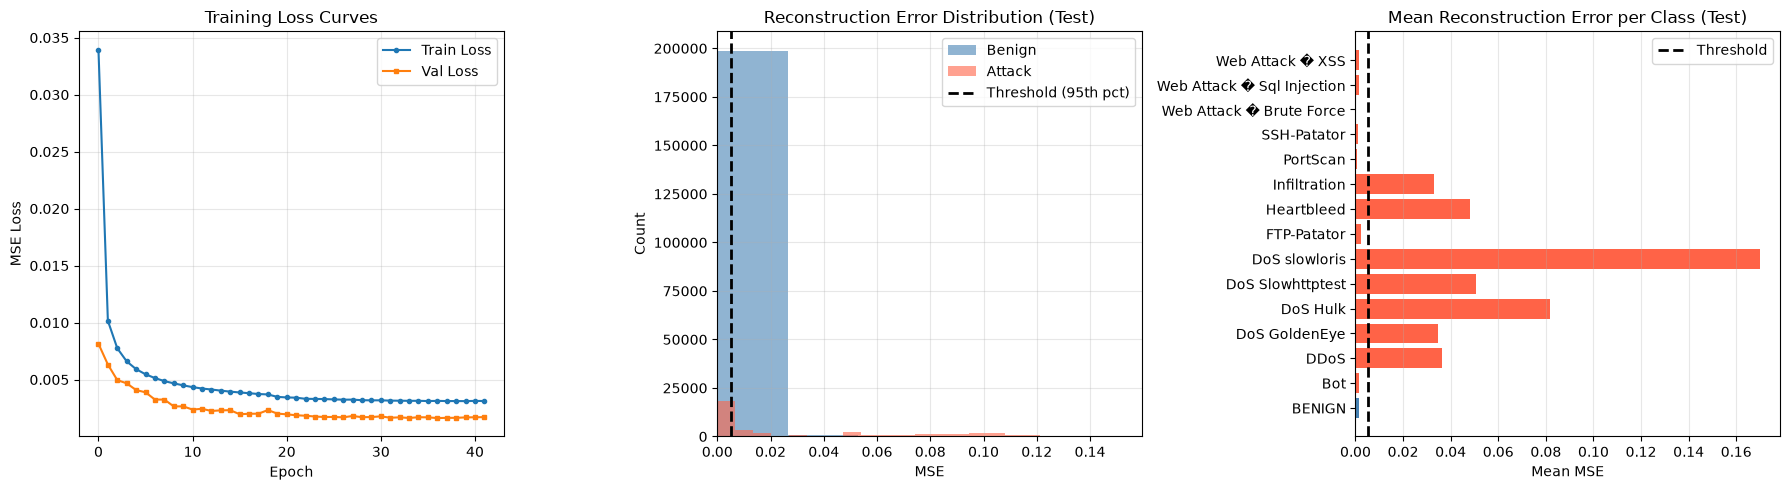

✅ Saved: autoencoder_plots.png


In [17]:
# Section 9: Plot Training Curves and Error Distributions
print("\n📈 GENERATING PLOTS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', marker='o', markersize=3)
axes[0].plot(history.history['val_loss'], label='Val Loss',   marker='s', markersize=3)
axes[0].set_title('Training Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

benign_test_mse = test_mse[y_test == 0]
attack_test_mse = test_mse[y_test != 0]
clip_max        = np.percentile(test_mse, 99)

axes[1].hist(benign_test_mse, bins=100, alpha=0.6, label='Benign', color='steelblue')
axes[1].hist(attack_test_mse, bins=100, alpha=0.6, label='Attack', color='tomato')
axes[1].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({THRESHOLD_PERCENTILE})')
axes[1].set_title('Reconstruction Error Distribution (Test)')
axes[1].set_xlabel('MSE')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, clip_max)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

class_names, class_mse = [], []
for idx, name in sorted(reverse_map.items()):
    mask = y_test == idx
    if mask.sum() == 0:
        continue
    class_names.append(name)
    class_mse.append(test_mse[mask].mean())

colors = ['steelblue' if n == reverse_map.get(0, 'BENIGN') else 'tomato' for n in class_names]
axes[2].barh(class_names, class_mse, color=colors)
axes[2].axvline(threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[2].set_title('Mean Reconstruction Error per Class (Test)')
axes[2].set_xlabel('Mean MSE')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../trained_models/autoencoder_plots.png', dpi=150)
plt.show()
print('✅ Saved: autoencoder_plots.png')

## 10. Save Model, Threshold and Metrics

In [21]:
import json
import joblib

print("\n💾 SAVING AUTOENCODER (PRODUCTION SAFE)")
print("=" * 60)

# =========================
# 1. SAVE MODELS
# =========================
autoencoder.save('../trained_models/autoencoder.keras')
encoder_model.save('../trained_models/encoder_only.keras')

print("✅ autoencoder.keras")
print("✅ encoder_only.keras")



# =========================
# 3. SAVE FEATURE SCHEMA (CRITICAL FIX)
# =========================
feature_schema = {
    "feature_count": int(INPUT_DIM),
    "feature_order": list(range(INPUT_DIM))  # replace with real column names if available
}

with open('../trained_models/feature_schema.json', 'w') as f:
    json.dump(feature_schema, f, indent=2)

print("✅ feature_schema.json")

# =========================
# 4. SAVE THRESHOLD (ENHANCED)
# =========================
threshold_data = {
    'threshold': float(threshold),
    'threshold_name': THRESHOLD_PERCENTILE,
    'train_mse_mean': float(train_mse.mean()),
    'train_mse_std': float(train_mse.std()),
    'val_f1_at_threshold': float(best_f1),
    'note': 'mean+2std or tuned percentile from validation set'
}

with open('../trained_models/autoencoder_threshold.json', 'w') as f:
    json.dump(threshold_data, f, indent=2)

print("✅ autoencoder_threshold.json")

# =========================
# 5. SAVE METRICS
# =========================
metrics_out = {
    'model_type': 'Denoising Autoencoder (Unsupervised)',
    'input_dim': int(INPUT_DIM),
    'encoding_dim': int(ENCODING_DIM),
    'noise_factor': float(NOISE_FACTOR),
    'threshold': float(threshold),
    'threshold_name': THRESHOLD_PERCENTILE,
    'training_time_sec': float(training_time),
    'epochs_run': int(epochs_run),
    'train_benign_samples': int(X_train_benign.shape[0]),
    'val_samples': int(len(y_val)),
    'test_samples': int(len(y_test)),
    'accuracy': float(acc),
    'precision': float(prec),
    'recall': float(rec),
    'f1_score': float(f1),
    'detection_rate': float(detection_rate),
    'false_positive_rate': float(false_positive_rate)
}

with open('../trained_models/autoencoder_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print("✅ autoencoder_metrics.json")

# =========================
# FINAL SUMMARY
# =========================
print("\n" + "="*60)
print("FINAL SUMMARY (PRODUCTION READY)")
print("="*60)
print(f"Threshold      : {threshold:.6f} ({THRESHOLD_PERCENTILE})")
print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1-Score       : {f1:.4f}")
print(f"Detection Rate : {detection_rate:.1%}")
print(f"FP Rate        : {false_positive_rate:.1%}")

print("\n✅ Autoencoder pipeline fully saved and production-safe")
print("➡ Next: 05_ensemble.ipynb")


💾 SAVING AUTOENCODER (PRODUCTION SAFE)
✅ autoencoder.keras
✅ encoder_only.keras
✅ feature_schema.json
✅ autoencoder_threshold.json
✅ autoencoder_metrics.json

FINAL SUMMARY (PRODUCTION READY)
Threshold      : 0.005189 (95th pct)
Accuracy       : 0.8853
Precision      : 0.7074
Recall         : 0.5726
F1-Score       : 0.6329
Detection Rate : 57.3%
FP Rate        : 4.9%

✅ Autoencoder pipeline fully saved and production-safe
➡ Next: 05_ensemble.ipynb
